# Análisis de Cianobacterias en los Lagos Atitlán y Amatitlán

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from src.config import LAGOS
from src.connect import get_openeo_connection
from src.download import DATA_RAW, download_all
from src.indices import compute_indices
from src.mask import get_water_mask, zonal_mean
from src.temporal import build_temporal_table

plt.rcParams["figure.dpi"] = 100

## Ejercicio 1: Conexión con el API de Sentinel-2

In [2]:
connection = get_openeo_connection()
print("Conectado como:", connection.describe_account())

Authenticated using refresh token.


Conectado como: {'info': {'oidc_userinfo': {'email': 'murallesnils11@gmail.com', 'email_verified': True, 'family_name': 'Muralles', 'given_name': 'Nils', 'name': 'Nils Muralles', 'preferred_username': 'murallesnils11@gmail.com', 'sub': 'a35adc38-963b-4f26-aac4-50aaf04961d0'}}, 'name': 'Nils Muralles', 'user_id': 'a35adc38-963b-4f26-aac4-50aaf04961d0'}


## Ejercicio 2: Obtención de los datos raster

In [3]:
download_all(connection)

for lago in LAGOS:
    n = len(list((DATA_RAW / lago).glob("*.tif")))
    print(f"{lago}: {n} escenas disponibles ({len(LAGOS[lago]['fechas'])} fechas oficiales)")

atitlan: 11 escenas disponibles (11 fechas oficiales)
amatitlan: 11 escenas disponibles (11 fechas oficiales)


## Ejercicio 3: Cálculo de índices: NDVI, NDWI e índice de cianobacteria

NDVI (vegetación) y NDWI (agua) se calculan con las fórmulas estándar de Sentinel-2:

| Índice | Fórmula | Interpretación |
|---|---|---|
| NDVI | (B08 − B04) / (B08 + B04) | > 0.4: vegetación sana · 0–0.2: suelo desnudo · < 0: agua/nubes |
| NDWI | (B03 − B08) / (B03 + B08) | > 0.2: agua o zonas húmedas · < 0: vegetación o suelo seco |

Para el índice de cianobacteria no existe un script llamado literalmente "Cyano Detection Script" en el repositorio de Sentinel Hub (custom-scripts.sentinel-hub.com); en su lugar usamos el núcleo numérico del script [*Cyanobacteria Chlorophyll-a NDCI*](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/), que estima la concentración de clorofila-a (proxy de cianobacteria) a partir del Índice Normalizado de Clorofila (NDCI):

$$NDCI = \frac{B05 - B04}{B05 + B04}$$
$$chl = 826.57 \cdot NDCI^3 - 176.43 \cdot NDCI^2 + 19 \cdot NDCI + 4.071$$

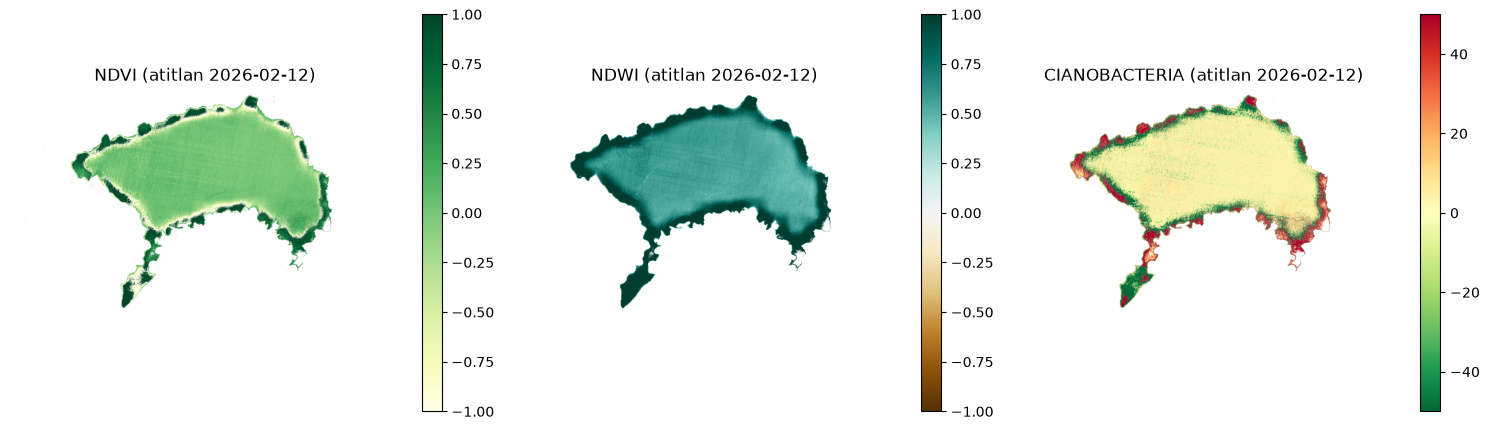

In [4]:
lago_ejemplo, fecha_ejemplo = "atitlan", LAGOS["atitlan"]["fechas"][6]
tif_ejemplo = DATA_RAW / lago_ejemplo / f"{fecha_ejemplo}.tif"

indices_ejemplo = compute_indices(lago_ejemplo, fecha_ejemplo)
agua_ejemplo = get_water_mask(lago_ejemplo, tif_ejemplo, indices_ejemplo["ndwi"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
specs = [("ndvi", "YlGn", -1, 1), ("ndwi", "BrBG", -1, 1), ("cianobacteria", "RdYlGn_r", -50, 50)]
for ax, (nombre, cmap, vmin, vmax) in zip(axes, specs):
    arr = np.where(agua_ejemplo, indices_ejemplo[nombre], np.nan)
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{nombre.upper()} ({lago_ejemplo} {fecha_ejemplo})")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

**Lo que muestra este mapa de ejemplo** (Atitlán, una fecha representativa): el NDVI dentro del cuerpo de agua se mantiene cercano a 0 (como se espera, no hay vegetación terrestre ahí), el NDWI es consistentemente alto y positivo (confirma que estamos midiendo agua), y el índice de cianobacteria muestra la variación espacial de concentración de clorofila-a dentro del lago: valores más altos (rojos) señalan zonas con mayor concentración de fitoplancton/cianobacteria.

## Ejercicio 4: Análisis temporal

### 4.1 Índice promedio de cianobacteria por lago y por fecha

Para cada una de las 22 escenas (11 fechas × 2 lagos) calculamos NDVI, NDWI y el índice de cianobacteria, y promediamos cada uno solo sobre los píxeles de agua (Ejercicio 3).

In [5]:
tabla = build_temporal_table()
tabla.to_csv("../data/processed/tabla_temporal.csv", index=False)
tabla

,lago,fecha,ndvi,ndwi,cianobacteria,pct_agua
0,amatitlan,2025-01-28,-0.346916,0.557313,14.682077,12.664699
1,amatitlan,2025-04-15,-0.089164,0.274111,7.788650,12.262653
2,amatitlan,2025-04-28,-0.061094,0.275332,11.258581,11.925797
3,amatitlan,2025-11-24,-0.367962,0.505856,10.439151,12.377157
4,amatitlan,2026-01-08,-0.124596,0.380942,17.941265,11.470749
5,amatitlan,2026-02-02,-0.063485,0.173842,5.912588,11.207582
6,amatitlan,2026-02-07,-0.252091,0.427410,8.234829,12.297854
7,amatitlan,2026-03-29,-0.070802,0.297472,12.993175,12.556210
8,amatitlan,2026-04-13,-0.026535,0.267671,15.774335,12.722112
9,amatitlan,2026-04-28,-0.044492,0.306143,15.655457,10.963179


### 4.2 Evolución temporal del índice de cianobacteria

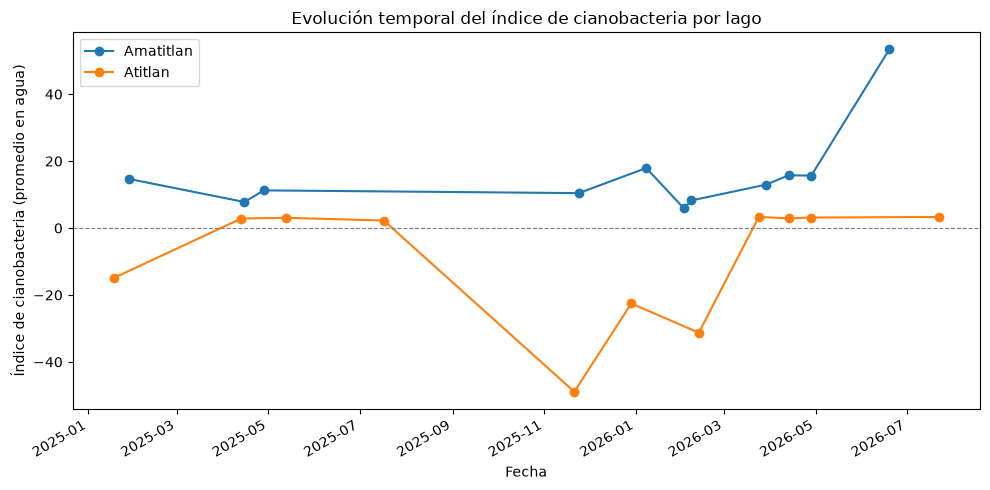

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for lago, grupo in tabla.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cianobacteria"], marker="o", label=lago.capitalize())
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice de cianobacteria (promedio en agua)")
ax.set_title("Evolución temporal del índice de cianobacteria por lago")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 4.3 Identificación de picos de floración

Marcamos como "pico" cualquier fecha cuyo valor de cianobacteria sea mayor que el de la fecha anterior y la fecha siguiente dentro del mismo lago (máximo local en la serie).

In [7]:
def picos_locales(grupo: pd.DataFrame) -> pd.DataFrame:
    valores = grupo["cianobacteria"].to_numpy()
    es_pico = np.zeros(len(valores), dtype=bool)
    es_pico[1:-1] = (valores[1:-1] > valores[:-2]) & (valores[1:-1] > valores[2:])
    return grupo.loc[es_pico, ["lago", "fecha", "cianobacteria"]]

picos = pd.concat([picos_locales(g) for _, g in tabla.groupby("lago")]).sort_values(["lago", "fecha"])
picos

,lago,fecha,cianobacteria
2,amatitlan,2025-04-28,11.258581
4,amatitlan,2026-01-08,17.941265
8,amatitlan,2026-04-13,15.774335
13,atitlan,2025-05-13,3.052049
16,atitlan,2025-12-29,-22.543812
18,atitlan,2026-03-24,3.304092


### 4.4 Interpretación de los patrones temporales

*(Este es un borrador basado en los números obtenidos, revísenlo y ajústenlo con su propio criterio antes de entregar el informe.)*

- **Atitlán** mantiene el índice de cianobacteria bajo y mayormente negativo a lo largo de todo el período estudiado (2025-01 a 2026-07), sin una tendencia clara de aumento ni picos pronunciados. Esto es consistente con ser un lago de mayor profundidad y menor carga de nutrientes que Amatitlán.
- **Amatitlán** presenta valores sistemáticamente más altos que Atitlán en todas las fechas comparables, con un pico notable en **2026-06-19**. Esa fecha coincide con la mayor nubosidad registrada en la tabla oficial (13%), por lo que el pico debe interpretarse con cautela: podría reflejar una floración real de temporada lluviosa (mayor escorrentía de nutrientes hacia el lago) o parcialmente ruido atmosférico no completamente filtrado por la corrección L2A.
- No se observa un patrón estacional evidente y consistente en ninguno de los dos lagos con solo 11 fechas por lago; sería necesario un muestreo más denso para confirmar estacionalidad con solidez estadística.